In [1]:
from time_series_gan.WGAN import WGAN
import numpy as np
import pandas as pd
from time_series_gan.metrics import dWasserstein, dFrechet, ONND, score
from Optimisation_MH import generer_resultats, Metropolis_Hasting

c:\Users\sducr\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("data/data_genhack.csv")
# archi = Metropolis_Hasting(0.1, data, WGAN, ite = 1000, metrique=score, nom_de_la_métrique = "score")

In [3]:
params = {'lr_g': 0.0008328, 'lr_c': 0.008314, 'epochs': 140, 'batch_size': 89, 'latent_dim': 9, 'n_critic': 1, 'lambda_gp': 0.2247}
archi = {'generator': {'architecture': 'MLP', 'layer_sizes': [15, 4], 'activation': 'ReLU'}, 'critic': {'architecture': 'MLP', 'layer_sizes': [22, 64, 28, 1], 'activation': 'ReLU'}}

print(archi)

{'generator': {'architecture': 'MLP', 'layer_sizes': [15, 4], 'activation': 'ReLU'}, 'critic': {'architecture': 'MLP', 'layer_sizes': [22, 64, 28, 1], 'activation': 'ReLU'}}


Epoch [1/140], C Loss: -189.9271, G Loss: -15.8569, Dwasserstein: 5.3645, Dfrechet: 17.2843, Onnd: 11.5512, Score: 81.0204
Epoch [2/140], C Loss: -151.1356, G Loss: -19.5455, Dwasserstein: 5.3140, Dfrechet: 16.3846, Onnd: 11.0796, Score: 78.7686
Epoch [3/140], C Loss: -166.6846, G Loss: -16.6592, Dwasserstein: 5.1220, Dfrechet: 16.0451, Onnd: 10.7737, Score: 77.5629
Epoch [4/140], C Loss: -170.1303, G Loss: -23.8576, Dwasserstein: 4.9524, Dfrechet: 16.4139, Onnd: 10.3360, Score: 74.6978
Epoch [5/140], C Loss: -142.1658, G Loss: -35.6362, Dwasserstein: 5.1432, Dfrechet: 15.1479, Onnd: 10.3098, Score: 73.2124
Epoch [6/140], C Loss: -136.3894, G Loss: -44.4369, Dwasserstein: 4.7976, Dfrechet: 14.5238, Onnd: 8.7342, Score: 69.5815
Epoch [7/140], C Loss: -138.7861, G Loss: -62.1624, Dwasserstein: 4.6165, Dfrechet: 13.9127, Onnd: 8.7189, Score: 69.1150
Epoch [8/140], C Loss: -115.1069, G Loss: -56.6659, Dwasserstein: 4.4101, Dfrechet: 13.3177, Onnd: 7.8875, Score: 63.9693
Epoch [9/140], C Lo

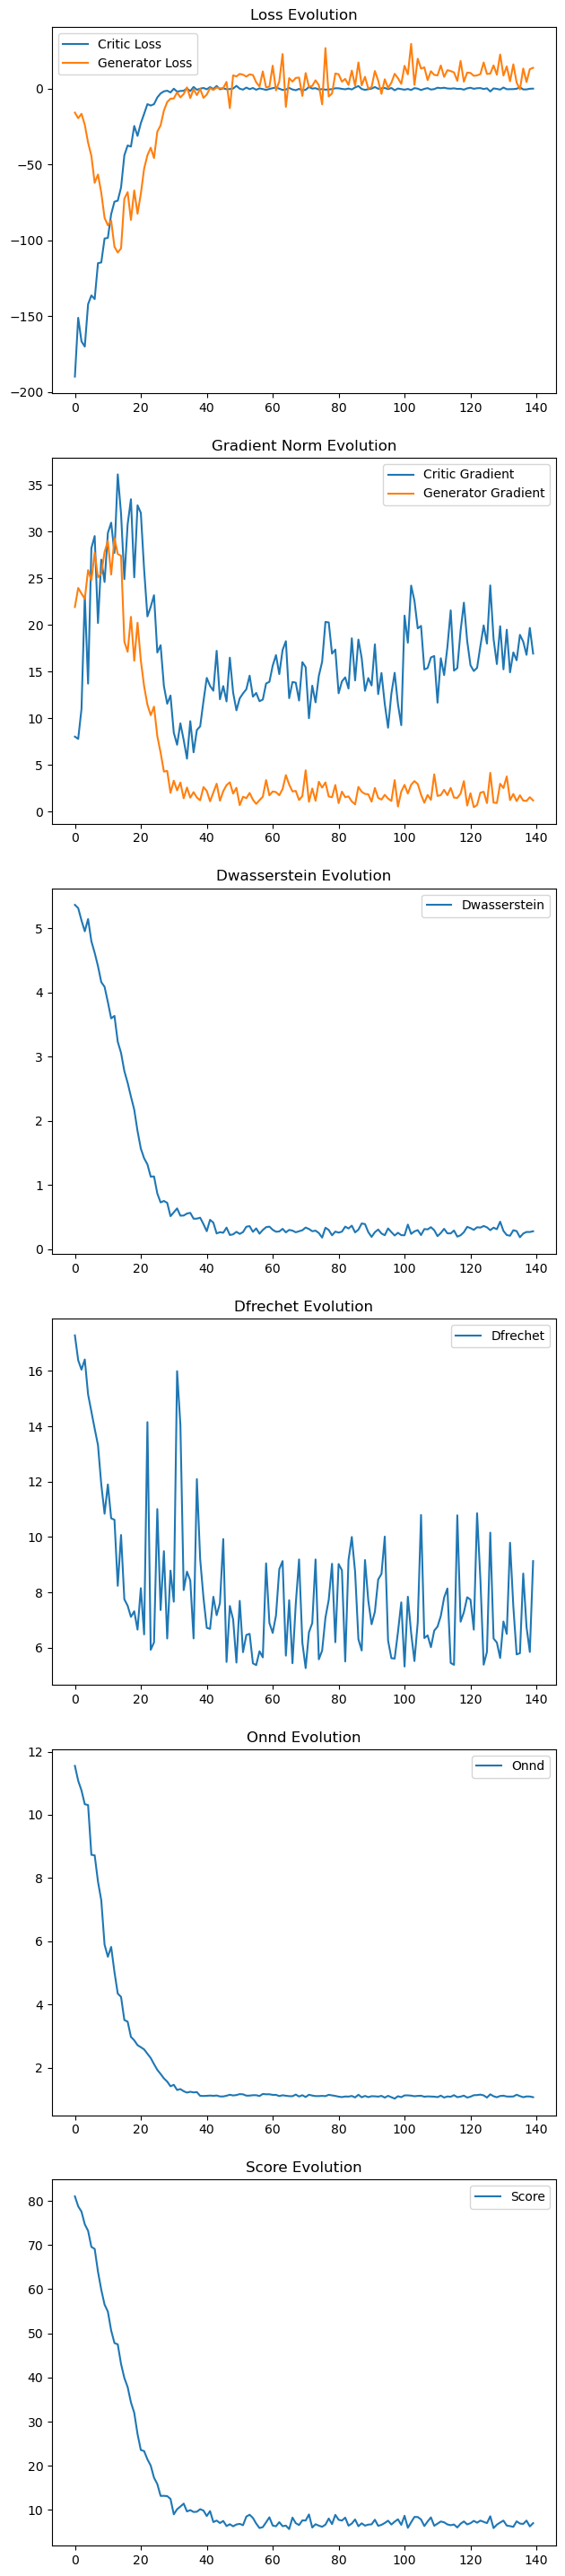

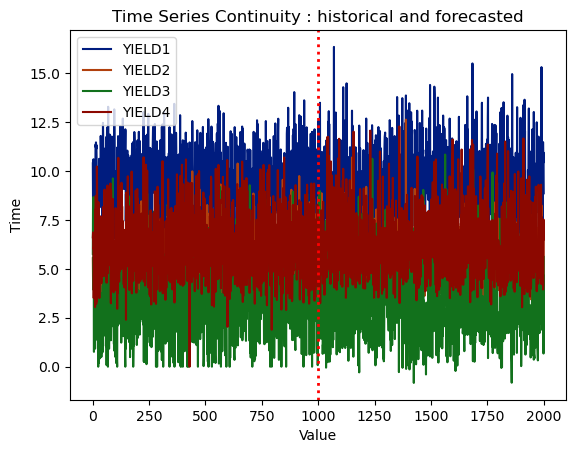

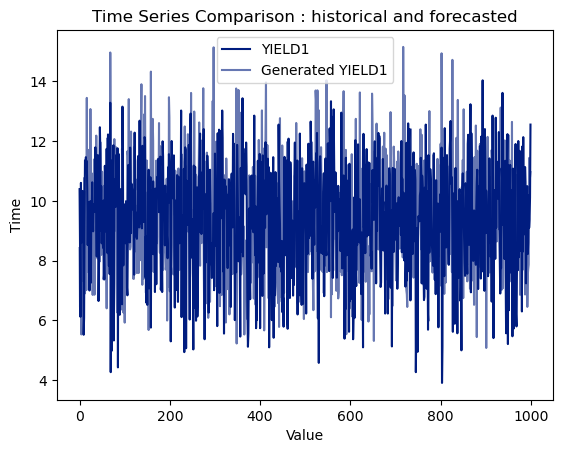

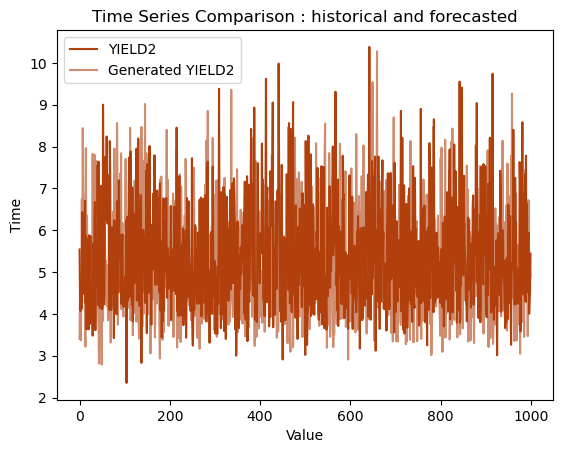

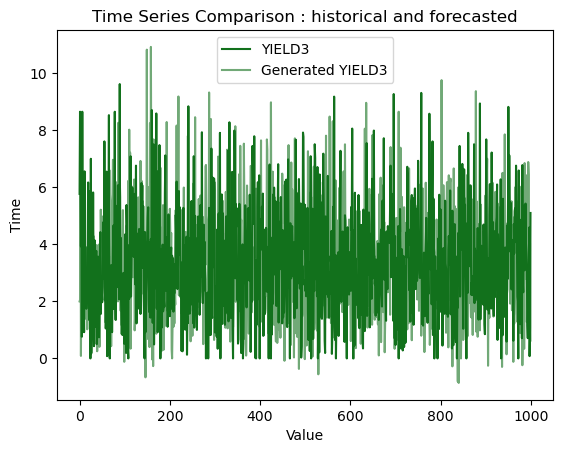

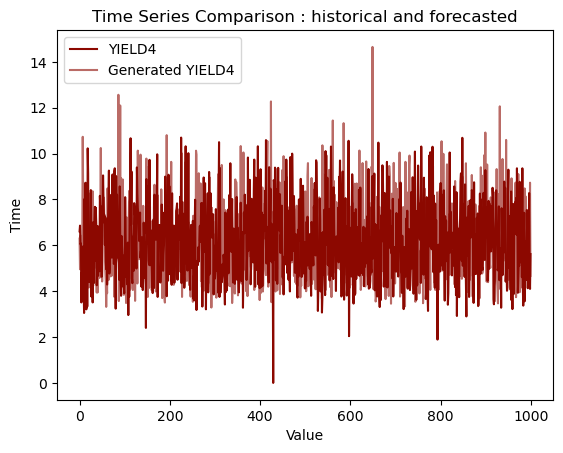

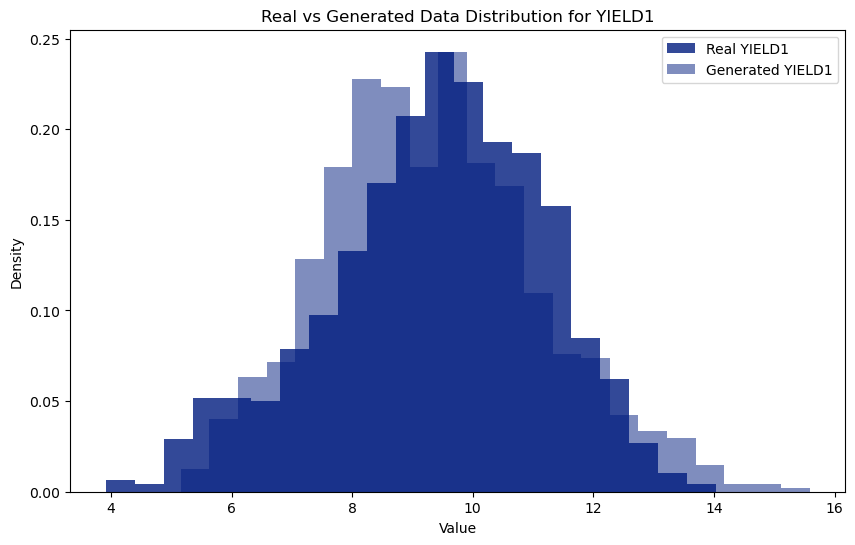

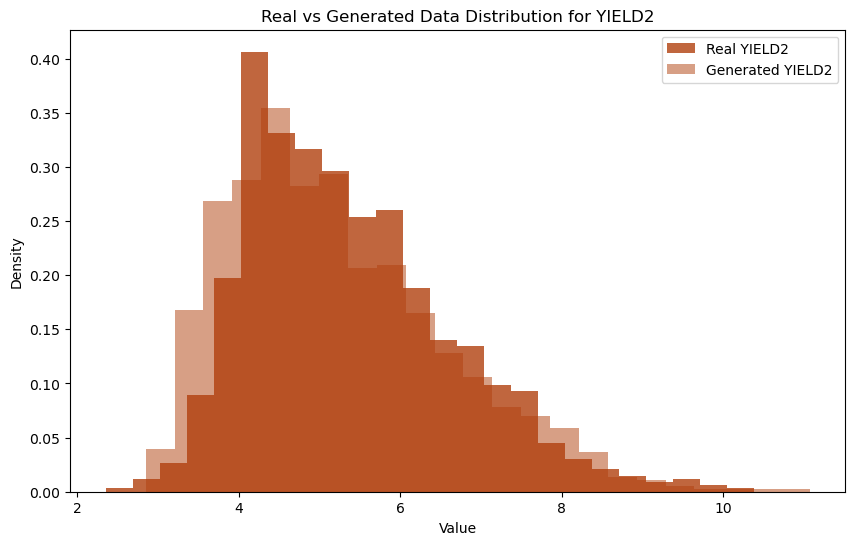

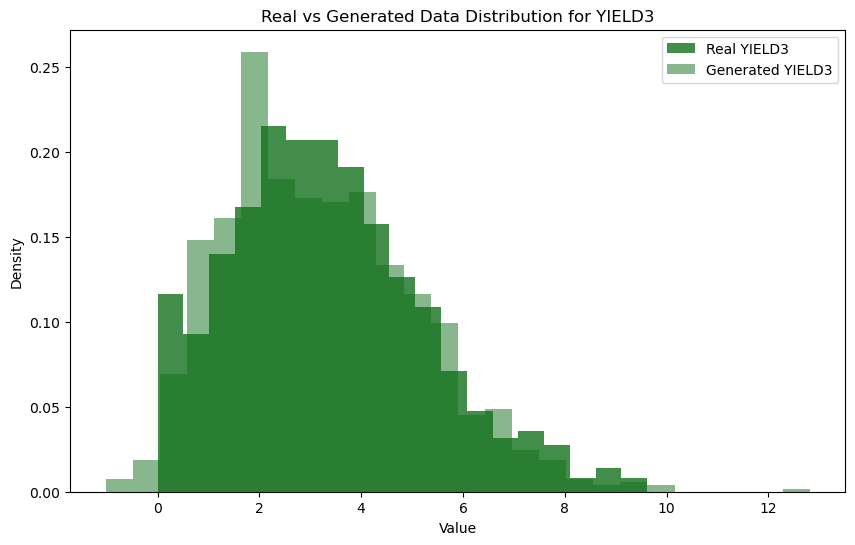

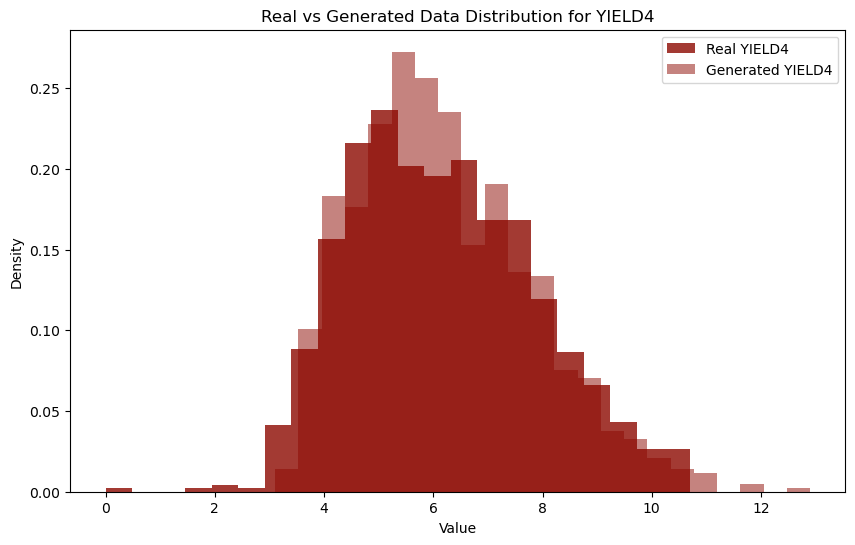

fit took 213.542802 seconds


{'dWasserstein': (0.17970071509439225, 0.2518039956699167),
 'dFrechet': (8.463580781383023, 5.817354556391911),
 'ONND': (0.7918209583097248, 1.0695560587114594),
 'score': (6.3452898728100555, 6.796714159134859)}

In [33]:
model = WGAN()
model.set_data(data)
model.set_metrics({'dWasserstein': {'function':dWasserstein, 'metric_args': {}}, 'dFrechet': {'function':dFrechet, 'metric_args': {}}, 'ONND': {'function':ONND, 'metric_args': {}}, 'score': {'function':score, 'metric_args': {}}})
model.fit(architectures = archi, params = params, verbose = True)
# model.fit_hyperparameters({"lr_g": [5e-6, 5e-3], "lr_d": [5e-6, 5e-3], "epochs": [50, 150], "batch_size": [8,300], "latent_dim": [1,150], "n_critic" : [1, 5], "lambda_gp" : [0.01, 0.5]}, n_trials = 100)

In [34]:
n = 20

w = np.array([model.compute_val_metric(dWasserstein, {}) for _ in range(n)])
print("Wasserstein", w.mean(), w.std())

f = np.array([model.compute_val_metric(dFrechet, {}) for _ in range(n)])
print("Fréchet", f.mean(), f.std())

o = np.array([model.compute_val_metric(ONND, {}) for _ in range(n)])
print("ONND", o.mean(), o.std())

s = np.array([model.compute_val_metric(score, {}) for _ in range(n)])
print("Score", s.mean(), s.std())

Wasserstein 0.2491874426597437 0.03580197916450876
Fréchet 6.9888698051999665 2.029498931156367
ONND 1.0872866701705768 0.025445371417245594
Score 6.472880218208488 0.8141036746301645
